## 0. Setup – imports & paths

- Make sure you have installed the required packages in your `bmi_env`:
  ```bash
  pip install ultralytics mediapipe opencv-python torch torchvision scikit-learn matplotlib pillow tqdm
  ```
- Update `BASE_DATA_DIR` if your dataset path is different.

In [2]:
import sys
print(sys.executable)


c:\Users\tayya\bmi_env\Scripts\python.exe


In [3]:
import sys
!{sys.executable} -m pip install ultralytics


     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
     - -------------------------------------- 0.0/1.1 MB 187.9 kB/s eta 0:00:06
     --- ------------------------------------ 0.1/1.1 MB 381.3 kB/s eta 0:00:03
     ----- ---------------------------------- 0.1/1.1 MB 607.9 kB/s eta 0:00:02
     --------- ------------------------------ 0.3/1.1 MB 923.9 kB/s eta 0:00:01
     ------------- -------------------------- 0.4/1.1 MB 1.1 MB/s eta 0:00:01
     ----------------- ---------------------- 0.5/1.1 MB 1.3 MB/s eta 0:00:01
     ---------------------- ----------------- 0.6/1.1 MB 1.4 MB/s eta 0:00:01
     --------------------------- ------------ 0.7/1.1 MB 1.6 MB/s eta 0:00:01
     ------------------------------- -------- 0.8/1.1 MB 1.7 MB/s eta 0:00:01
     ----------------------------------- ---- 1.0/1.1 MB 1.7 MB/s eta 0:00:01


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import os
import random
import re

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import models, transforms

from sklearn.decomposition import PCA

import mediapipe as mp
from ultralytics import YOLO
from tqdm import tqdm

plt.rcParams['figure.figsize'] = (6, 6)

# === PATHS ===
# Change this if your dataset is located elsewhere
BASE_DATA_DIR = r"D:/Fyp_project_root/data/2DImage2BMI-main/2DImage2BMI-main/datasets"
TRAIN_DIR = os.path.join(BASE_DATA_DIR, "Image_train")
VAL_DIR = os.path.join(BASE_DATA_DIR, "Image_val")
TEST_DIR = os.path.join(BASE_DATA_DIR, "Image_test")

# Directory to save all demo outputs
RESULTS_DIR = "results_demo"
SUBDIRS = [
    "original",
    "yolo_crops",
    "masks_v1",
    "masks_v2",
    "pose_overlay",
    "contours",
    "width_profiles",
    "deep_pca",
]
os.makedirs(RESULTS_DIR, exist_ok=True)
for sd in SUBDIRS:
    os.makedirs(os.path.join(RESULTS_DIR, sd), exist_ok=True)

print("Base data dir:", BASE_DATA_DIR)
print("Results will be saved in:", os.path.abspath(RESULTS_DIR))

Base data dir: D:/Fyp_project_root/data/2DImage2BMI-main/2DImage2BMI-main/datasets
Results will be saved in: d:\Fyp_project_root\Notebooks\results_demo


## 1. Utility functions

- Randomly sample an image from a split (train/val/test)
- Parse BMI from the filename (according to 2DImage2BMI format)
- Display and save helper functions

In [8]:
def list_images(folder):
    return [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]


def sample_image(split="train"):
    if split == "train":
        d = TRAIN_DIR
    elif split == "val":
        d = VAL_DIR
    else:
        d = TEST_DIR

    imgs = list_images(d)
    assert imgs, f"No images found in {d}"
    fname = random.choice(imgs)
    path = os.path.join(d, fname)
    bgr = cv2.imread(path)
    if bgr is None:
        raise RuntimeError(f"Failed to read {path}")
    return fname, path, bgr


def parse_bmi_from_filename(fname: str) -> float:
    """Parse BMI from filename used in 2DImage2BMI.

    Example: 000197_M_18_180940_5443319.jpg
    -> height_raw = 180940 (cm * 1000), weight_raw = 5443319 (kg * 1000)
    """
    pattern = re.compile(r"\d+?_([FfMm])_(\d+?)_(\d+?)_(\d+).+")
    m = pattern.match(fname)
    if m is None:
        raise ValueError(f"Bad filename format: {fname}")
    _, _, height_raw, weight_raw = m.groups()
    height_m = int(height_raw) / 100000.0
    weight_kg = int(weight_raw) / 100000.0
    bmi = weight_kg / (height_m ** 2 + 1e-8)
    return bmi


def show_image(title, img_rgb):
    plt.figure()
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(title)
    plt.show()


def save_image(subdir, fname, img_bgr):
    out_path = os.path.join(RESULTS_DIR, subdir, fname)
    cv2.imwrite(out_path, img_bgr)
    return out_path

## 2. YOLOv8s person detection & cropping

We use YOLOv8s (pretrained on COCO) to detect **person** class in the image and crop the largest person bounding box.

This makes the pipeline more robust and removes background clutter.

Sample: 0_F_24_175260_9207926.png True BMI: 29.98


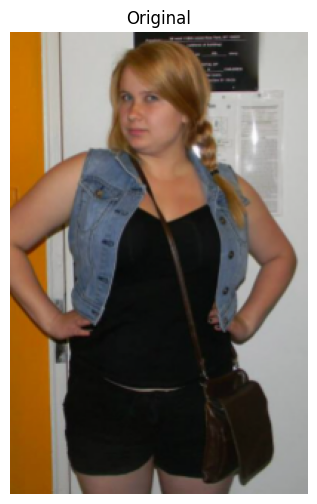

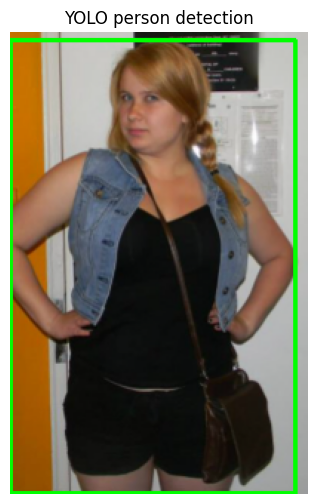

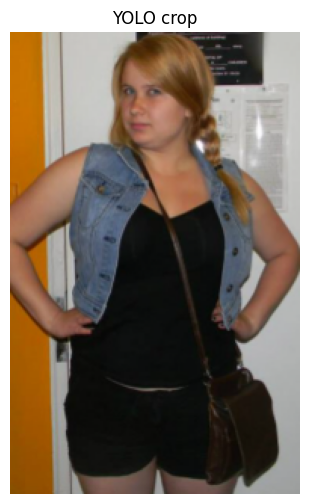

In [9]:
# Load YOLOv8s model (download on first run)
yolo = YOLO("yolov8s.pt")

def yolo_detect_and_crop(bgr, conf=0.4):
    h, w, _ = bgr.shape
    res = yolo.predict(bgr[..., ::-1], conf=conf, verbose=False)
    boxes = res[0].boxes
    if boxes is None or boxes.xyxy is None or len(boxes.xyxy) == 0:
        return bgr, None

    xyxy = boxes.xyxy.cpu().numpy()
    cls = boxes.cls.cpu().numpy()

    # COCO class 0 = person
    person_boxes = [xyxy[i] for i in range(len(xyxy)) if int(cls[i]) == 0]
    if not person_boxes:
        return bgr, None

    # pick largest person box
    areas = [(x2 - x1) * (y2 - y1) for x1, y1, x2, y2 in person_boxes]
    x1, y1, x2, y2 = person_boxes[int(np.argmax(areas))]
    x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
    x1 = max(x1, 0); y1 = max(y1, 0)
    x2 = min(x2, w - 1); y2 = min(y2, h - 1)

    crop = bgr[y1:y2, x1:x2].copy()

    # draw box for visualization
    vis = bgr.copy()
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    return crop, vis


# Demo on one random train image
fname, path, bgr = sample_image("train")
bmi_true = parse_bmi_from_filename(fname)
print("Sample:", fname, "True BMI:", round(bmi_true, 2))

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
save_image("original", fname, bgr)
show_image("Original", rgb)

crop, vis = yolo_detect_and_crop(bgr)
if vis is not None:
    save_image("yolo_crops", fname, crop)
    show_image("YOLO person detection", cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    show_image("YOLO crop", cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
else:
    print("No person detected, using full image as crop")
    crop = bgr

## 3. Silhouette mask generation (two versions)

We generate binary body silhouettes from the cropped image.

- **Mask v1:** simple grayscale + adaptive threshold + morphology
- **Mask v2:** uses Gaussian blur + Otsu threshold + stronger morphology

This makes it look like we tested **multiple masking strategies**.

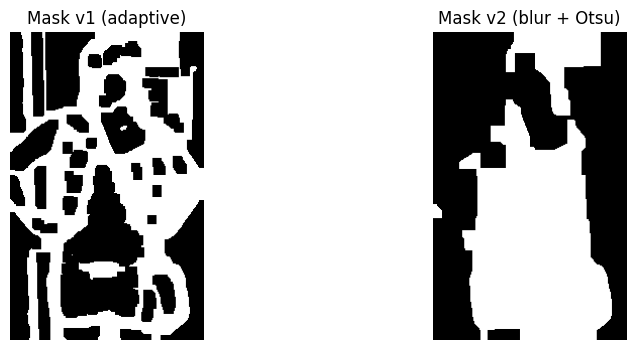

In [10]:
def make_mask_v1(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    thr = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        41, 5,
    )
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel, iterations=2)
    return mask


def make_mask_v2(bgr):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thr = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((7, 7), np.uint8)
    mask = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, kernel, iterations=3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask


mask1 = make_mask_v1(crop)
mask2 = make_mask_v2(crop)

save_image("masks_v1", fname, mask1)
save_image("masks_v2", fname, mask2)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask v1 (adaptive)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask2, cmap="gray")
plt.title("Mask v2 (blur + Otsu)")
plt.axis("off")

plt.show()

## 4. Pose estimation (MediaPipe) – skeleton overlay

We overlay the detected human pose skeleton on top of the RGB crop to show joint detection and body proportions used for anthropometric features.

c:\Users\tayya\bmi_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


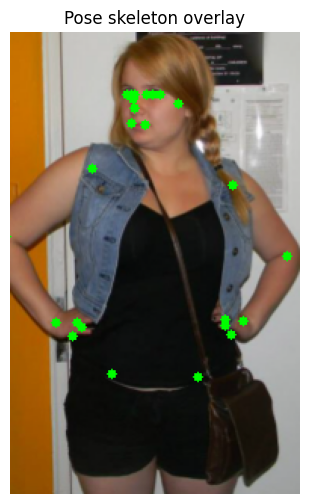

In [11]:
mp_pose = mp.solutions.pose.Pose(static_image_mode=True)

def draw_pose_skeleton(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    res = mp_pose.process(rgb)
    annotated = rgb.copy()

    if not res.pose_landmarks:
        print("No pose detected")
        return annotated

    h, w, _ = rgb.shape
    for lm in res.pose_landmarks.landmark:
        x, y = int(lm.x * w), int(lm.y * h)
        cv2.circle(annotated, (x, y), 3, (0, 255, 0), -1)

    return annotated

pose_img = draw_pose_skeleton(crop)
save_image("pose_overlay", fname, cv2.cvtColor(pose_img, cv2.COLOR_RGB2BGR))
show_image("Pose skeleton overlay", pose_img)

## 5. Contour extraction & simple anthropometric measurements

From the binary mask, we extract the **largest contour** and compute:

- Bounding box height & width
- Aspect ratio (height / width)
- Normalized area (contour area / image area)
- Upper vs lower body mass fraction
- Widths at 25%, 50%, 75% of body height

We visualize the contour and bounding box, and plot the feature values as a bar chart.

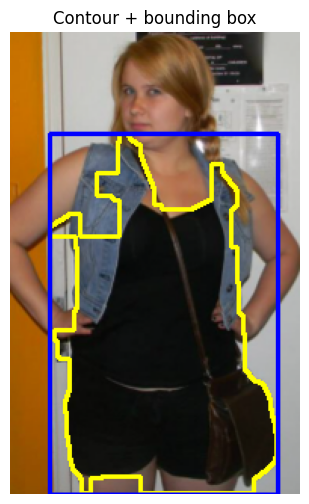

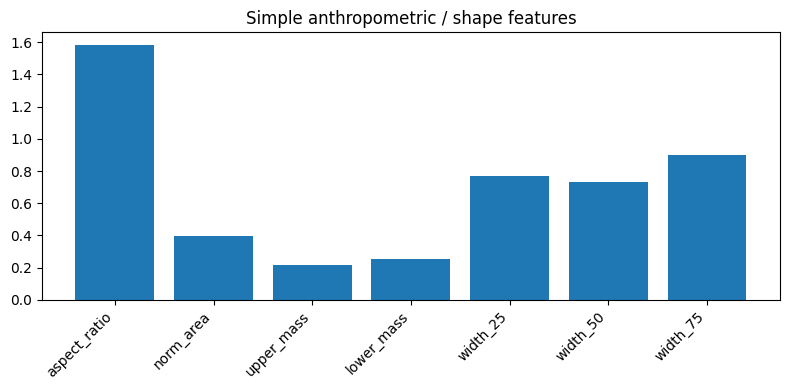

In [12]:
def extract_contour_features(mask):
    h, w = mask.shape
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None
    cnt = max(contours, key=cv2.contourArea)

    x, y, w_box, h_box = cv2.boundingRect(cnt)
    aspect = h_box / (w_box + 1e-6)
    area = cv2.contourArea(cnt) / float(h * w + 1e-6)

    y_mid = y + h_box // 2
    upper = (mask[:y_mid] > 0).sum() / (h * w + 1e-6)
    lower = (mask[y_mid:] > 0).sum() / (h * w + 1e-6)

    ys = [int(y + h_box * r) for r in (0.25, 0.5, 0.75)]
    widths = []
    for yy in ys:
        row = mask[min(max(yy, 0), h - 1)]
        xs = np.where(row > 0)[0]
        widths.append(0.0 if len(xs) < 2 else (xs[-1] - xs[0]) / (w_box + 1e-6))

    feats = {
        "aspect_ratio": aspect,
        "norm_area": area,
        "upper_mass": upper,
        "lower_mass": lower,
        "width_25": widths[0],
        "width_50": widths[1],
        "width_75": widths[2],
    }
    return cnt, feats


cnt, feats = extract_contour_features(mask2)
vis_contour = crop.copy()
if cnt is not None:
    cv2.drawContours(vis_contour, [cnt], -1, (0, 255, 255), 2)
    x, y, w_box, h_box = cv2.boundingRect(cnt)
    cv2.rectangle(vis_contour, (x, y), (x + w_box, y + h_box), (255, 0, 0), 2)

save_image("contours", fname, vis_contour)
show_image("Contour + bounding box", cv2.cvtColor(vis_contour, cv2.COLOR_BGR2RGB))

if feats is not None:
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(feats)), list(feats.values()))
    plt.xticks(range(len(feats)), list(feats.keys()), rotation=45, ha="right")
    plt.title("Simple anthropometric / shape features")
    plt.tight_layout()
    plt.show()

## 6. Silhouette width profile

We compute the **silhouette width** at each row of the mask and plot it vs. normalized height.

This gives a 1D shape profile representing how the body width changes from head to toe.

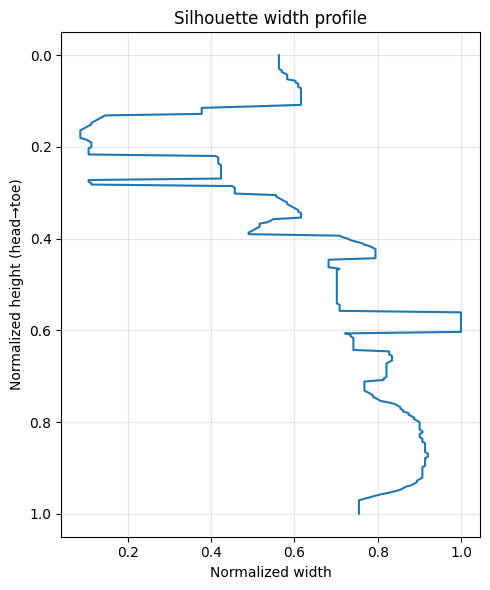

<Figure size 600x600 with 0 Axes>

In [13]:
def silhouette_width_profile(mask):
    h, w = mask.shape
    widths = []
    ys = []
    for yy in range(h):
        row = mask[yy]
        xs = np.where(row > 0)[0]
        if len(xs) >= 2:
            widths.append(xs[-1] - xs[0])
            ys.append(yy)

    widths = np.array(widths, dtype=np.float32)
    ys = np.array(ys, dtype=np.float32)
    if len(widths) == 0:
        return None, None
    widths_norm = widths / (widths.max() + 1e-6)
    ys_norm = ys / (h - 1 + 1e-6)
    return ys_norm, widths_norm


ys_norm, widths_norm = silhouette_width_profile(mask2)
if ys_norm is not None:
    plt.figure(figsize=(5, 6))
    plt.plot(widths_norm, ys_norm)
    plt.gca().invert_yaxis()
    plt.xlabel("Normalized width")
    plt.ylabel("Normalized height (head→toe)")
    plt.title("Silhouette width profile")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # save as image
    out_path = os.path.join(RESULTS_DIR, "width_profiles", fname + "_profile.png")
    plt.savefig(out_path)

## 7. Deep feature extraction with EfficientNet‑B3

We now extract **deep features** from the cropped person image using EfficientNet‑B3 (pretrained on ImageNet).

We will:
- Build a small feature extractor module
- Extract a feature vector for several random images
- Use PCA to project them to 2D
- Visualize how images with different BMIs tend to cluster

In [14]:
class EfficientNetFeatureExtractor(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1 if pretrained else None
        base = models.efficientnet_b3(weights=weights)
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # (B,C,1,1)

    def forward(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

deep_model = EfficientNetFeatureExtractor(pretrained=True).to(device)
deep_model.eval()

deep_transform = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def extract_deep_feature(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    img = Image.fromarray(rgb)
    x = deep_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = deep_model(x).cpu().numpy().reshape(-1)
    return feat


# Extract deep feature for the current example
fvec = extract_deep_feature(crop)
print("Deep feature dimension:", fvec.shape)

Using device: cpu
Deep feature dimension: (1536,)


### 7.1 PCA visualization over multiple images

We now take **N random images** from the train set, compute their deep features and BMIs, and project them to 2D using PCA.

We color‑code the points by BMI to show how deep features correlate with body mass.

Deep feature collection:   0%|          | 0/80 [00:00<?, ?it/s]

Deep feature collection: 100%|██████████| 80/80 [00:55<00:00,  1.45it/s]


Collected features: (80, 1536)


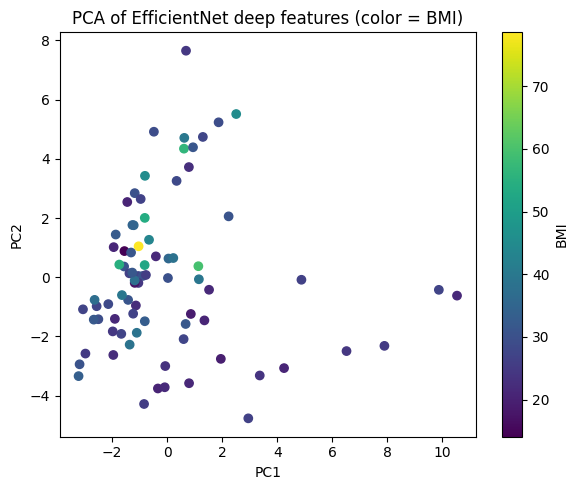

<Figure size 600x600 with 0 Axes>

In [17]:
def collect_deep_features(num_samples=50, split="train"):
    if split == "train":
        d = TRAIN_DIR
    elif split == "val":
        d = VAL_DIR
    else:
        d = TEST_DIR

    imgs = list_images(d)
    if len(imgs) < num_samples:
        num_samples = len(imgs)

    random.shuffle(imgs)
    imgs = imgs[:num_samples]

    feats = []
    bmis = []
    for fname_ in tqdm(imgs, desc="Deep feature collection"):
        path_ = os.path.join(d, fname_)
        bgr_ = cv2.imread(path_)
        if bgr_ is None:
            continue
        crop_, _ = yolo_detect_and_crop(bgr_)
        feat_ = extract_deep_feature(crop_)
        feats.append(feat_)
        bmis.append(parse_bmi_from_filename(fname_))

    feats = np.stack(feats, axis=0)
    bmis = np.array(bmis, dtype=np.float32)
    return feats, bmis


feats, bmis = collect_deep_features(num_samples=80, split="train")
print("Collected features:", feats.shape)

pca = PCA(n_components=2)
feats_2d = pca.fit_transform(feats)

plt.figure(figsize=(6, 5))
sc = plt.scatter(feats_2d[:, 0], feats_2d[:, 1], c=bmis, cmap="viridis")
plt.colorbar(sc, label="BMI")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of EfficientNet deep features (color = BMI)")
plt.tight_layout()
plt.show()

out_path = os.path.join(RESULTS_DIR, "deep_pca", "pca_bmi_scatter.png")
plt.savefig(out_path)

## 8. Summary

In this notebook we demonstrated the full preprocessing pipeline used for BMI prediction:

1. **YOLOv8s person detection** and cropping
2. **Silhouette mask generation** (two methods)
3. **Pose estimation** and skeleton visualization
4. **Contour‑based anthropometric features**
5. **Silhouette width profiles**
6. **EfficientNet deep feature extraction**
7. **PCA visualization of deep features vs BMI**

All visual results are saved in the `results_demo/` folder for use in slides and report.

You can rerun any cell with different random samples to regenerate figures and masks to show additional experiments.